In [2]:
# Import des librairies et packages nécessaires

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Lecture du fichier des données de sinistres 

df = pd.read_csv('insurance_claims.csv')

df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


Information sur le jeu de données

In [4]:
df.shape

(1000, 40)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

Statistique descriptives des variables

* Statistique descriptive de la variable 'months_as_customer

In [6]:
df['months_as_customer'].describe().round(2)

count    1000.00
mean      203.95
std       115.11
min         0.00
25%       115.75
50%       199.50
75%       276.25
max       479.00
Name: months_as_customer, dtype: float64

In [7]:
df.months_as_customer.value_counts()

months_as_customer
194    8
285    7
254    7
101    7
128    7
      ..
372    1
213    1
240    1
50     1
17     1
Name: count, Length: 391, dtype: int64

In [8]:
df.months_as_customer.nunique()

391

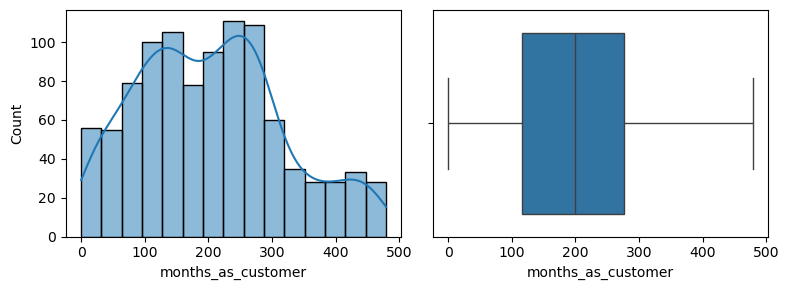

In [9]:
fig = plt.figure(figsize=(8,3))
sub1 = plt.subplot(1, 2, 1)
sns.histplot(df.months_as_customer, kde=True)
sub2 = plt.subplot(1, 2, 2)
sns.boxplot(df.months_as_customer, orient="h")
fig.tight_layout()
plt.show()

* Statistique descriptive de la variable 'age'

In [10]:
df.age.describe().round(2)

count    1000.00
mean       38.95
std         9.14
min        19.00
25%        32.00
50%        38.00
75%        44.00
max        64.00
Name: age, dtype: float64

In [11]:
df.age.value_counts()

age
43    49
39    48
41    45
34    44
31    42
38    42
30    42
37    41
33    39
40    38
32    38
29    35
46    33
42    32
35    32
44    32
36    32
28    30
26    26
45    26
48    25
47    24
27    24
57    16
55    14
49    14
25    14
50    13
53    13
61    10
24    10
54    10
51     9
60     9
56     8
58     8
23     7
21     6
59     5
62     4
52     4
64     2
63     2
19     1
20     1
22     1
Name: count, dtype: int64

In [12]:
df.age.nunique()

46

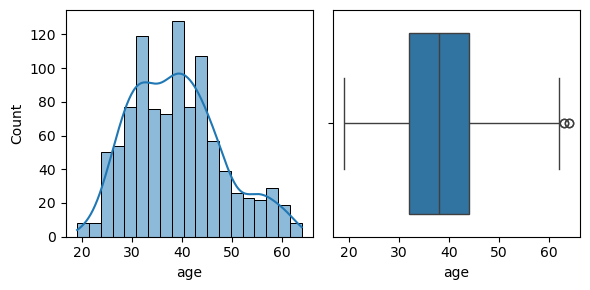

In [13]:
fig = plt.figure(figsize=(6,3))
sub1 = plt.subplot(1, 2, 1)
sns.histplot(df.age, kde=True)
sub2 = plt.subplot(1, 2, 2)
sns.boxplot(df.age, orient="h")
fig.tight_layout()
plt.show()

* Statistique descriptive de la variable 'policy_number'

In [14]:
df.policy_number.describe().round(2)

count      1000.00
mean     546238.65
std      257063.01
min      100804.00
25%      335980.25
50%      533135.00
75%      759099.75
max      999435.00
Name: policy_number, dtype: float64

In [15]:
df.policy_number.nunique()

1000

In [16]:
df.policy_number.value_counts()

policy_number
556080    1
521585    1
342868    1
687698    1
227811    1
         ..
842643    1
214618    1
543610    1
636550    1
485665    1
Name: count, Length: 1000, dtype: int64

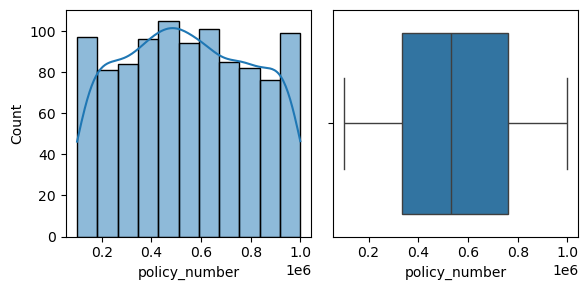

In [17]:
fig = plt.figure(figsize=(6,3))
sub1 = plt.subplot(1, 2, 1)
sns.histplot(df.policy_number, kde=True)
sub2 = plt.subplot(1, 2, 2)
sns.boxplot(df.policy_number, orient="h")
fig.tight_layout()
plt.show()

* Statistique descriptive de la variable 'policy_bind_date'
  - variable à transformer en format date 

In [18]:
df.policy_bind_date.describe().round(2)

count           1000
unique           951
top       1992-08-05
freq               3
Name: policy_bind_date, dtype: object

In [19]:
pd.to_datetime(df.policy_bind_date).value_counts()

policy_bind_date
1992-08-05    3
2006-01-01    3
1992-04-28    3
2004-01-03    2
1995-12-07    2
             ..
1991-07-16    1
2014-01-05    1
2003-02-17    1
2011-11-18    1
2004-06-14    1
Name: count, Length: 951, dtype: int64

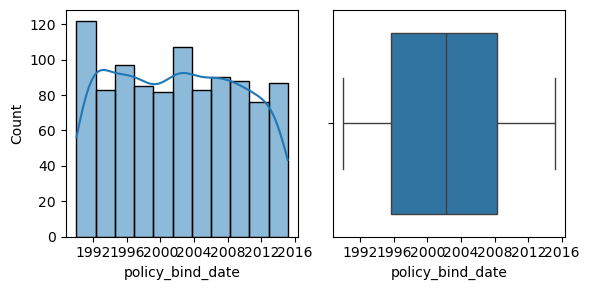

In [20]:
fig = plt.figure(figsize=(6,3))
sub1 = plt.subplot(1, 2, 1)
sns.histplot(pd.to_datetime(df.policy_bind_date), kde=True)
sub2 = plt.subplot(1, 2, 2)
sns.boxplot(pd.to_datetime(df.policy_bind_date), orient="h")
fig.tight_layout()
plt.show()

* Statistique descriptive de la variable 'policy_state'

In [21]:
df.policy_state.describe().round(2)

count     1000
unique       3
top         OH
freq       352
Name: policy_state, dtype: object

In [22]:
df.policy_state.value_counts()

policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64

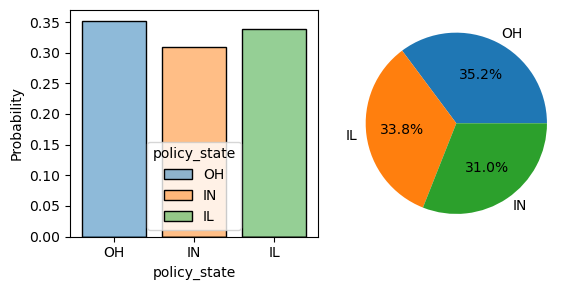

In [23]:
fig = plt.figure(figsize=(6,3))
sub1 = plt.subplot(1, 2, 1)

sns.histplot(data=df, x="policy_state", hue="policy_state", shrink=.8, stat="probability")
sub2 = plt.subplot(1, 2, 2)
state_counts = df.policy_state.value_counts()
plt.pie(state_counts.values, 
        labels=state_counts.index, 
        autopct='%1.1f%%')
fig.tight_layout()
plt.show()

In [42]:
# Fonction d'analyse descriptive des variables quantitatives
def analyse_variable_quantitative(variable, base):

    print()

    print("Statistiques de la variable: ", end="\n\n")

    print(base[variable].describe().round(2), end="\n\n")

    print("Nombre de valeur unique:")
    print(base[variable].nunique(), end="\n\n")
    
    print("Nombre d'occurences par valeur:")
    print(base[variable].value_counts(), end="\n\n")

    print("Pourcentage du nombre d'occurences par valeur en %:")
    print(base[variable].value_counts(normalize=True)*100, end="\n\n")

    
    print("Occurrence la moins fréquente:")
    print(base[variable].value_counts().idxmin(), end="\n\n")
    
    print("Occurrence la plus fréquente:")
    print(base[variable].value_counts().idxmax(), end="\n\n")
    
    print()

    fig = plt.figure(figsize=(8,4))
    
    sub1 = plt.subplot(2, 1, 1)
    
    sns.histplot(x=variable, kde=True, data=base)
    
    plt.title(f'Distribution de {variable} \n', fontsize=10)
    
    sub2 = plt.subplot(2, 1, 2)
    
    sns.boxplot(x=variable, orient="h", data=base)

    # plt.title(f'Distribution de {variable} \n', fontsize=10)

    plt.show()


In [ ]:
# Fonction d'analyse descriptive des variables quantitatives
def analyse_variable_qualitative(variable, base):

    print()

    print("Statistiques de la variable: ", end="\n\n")

    print(base[variable].describe().round(2), end="\n\n")

    print("Nombre de valeur unique:")
    print(base[variable].nunique(), end="\n\n")
    
    print("Nombre d'occurences par valeur:")
    print(base[variable].value_counts(), end="\n\n")

    print("Pourcentage du nombre d'occurences par valeur en %:")
    print(base[variable].value_counts(normalize=True)*100, end="\n\n")

    
    print("Occurrence la moins fréquente::")
    print(base[variable].value_counts().idxmin(), end="\n\n")
    
    print("Occurrence la plus fréquente::")
    print(base[variable].value_counts().idxmax(), end="\n\n")
    
    print()

    fig = plt.figure(figsize=(6,3))
    
    sub1 = plt.subplot(1, 2, 1)
    
    sns.histplot(data=df, x=variable, hue=variable, shrink=.8, stat="probability")
    plt.title(f'Distribution de {variable} \n', fontsize=10)
    
    sub2 = plt.subplot(1, 2, 2)
    
    sns.boxplot(x=variable, orient="h", data=base)

    plt.title(f'Distribution de {variable} \n', fontsize=10)

    plt.show()


* Analyse descriptive de la variable "policy_deductible"


Statistiques de la variable: 

count    1000.00
mean     1136.00
std       611.86
min       500.00
25%       500.00
50%      1000.00
75%      2000.00
max      2000.00
Name: policy_deductable, dtype: float64

Nombre de valeur unique:
3

Nombre d'occurences par valeur:
policy_deductable
1000    351
500     342
2000    307
Name: count, dtype: int64

Pourcentage du nombre d'occurences par valeur en %:
policy_deductable
1000    35.1
500     34.2
2000    30.7
Name: proportion, dtype: float64

Occurrence la moins fréquente::
2000

Occurrence la plus fréquente::
1000




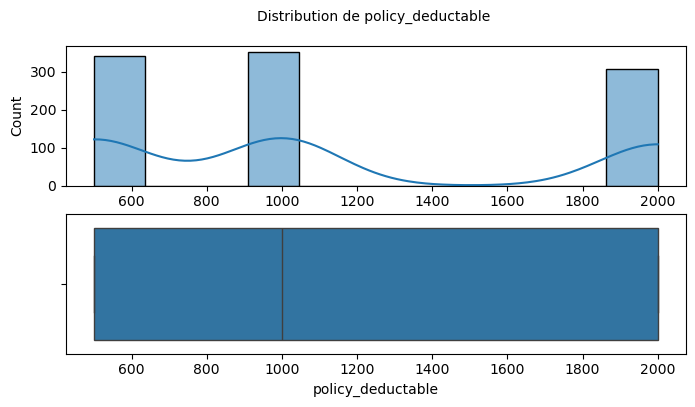

In [40]:
analyse_variable_quantitative('policy_deductable', df)


Statistiques de la variable: 

count    1000.00
mean     1256.41
std       244.17
min       433.33
25%      1089.61
50%      1257.20
75%      1415.70
max      2047.59
Name: policy_annual_premium, dtype: float64

Nombre de valeur unique:
991

Nombre d'occurences par valeur:
policy_annual_premium
1073.83    2
1074.07    2
1215.36    2
1362.87    2
1558.29    2
          ..
1310.80    1
1436.79    1
1383.49    1
1356.92    1
1413.14    1
Name: count, Length: 991, dtype: int64

Pourcentage du nombre d'occurences par valeur en %:
policy_annual_premium
1073.83    0.2
1074.07    0.2
1215.36    0.2
1362.87    0.2
1558.29    0.2
          ... 
1310.80    0.1
1436.79    0.1
1383.49    0.1
1356.92    0.1
1413.14    0.1
Name: proportion, Length: 991, dtype: float64

Occurrence la moins fréquente::
1351.1

Occurrence la plus fréquente::
1073.83




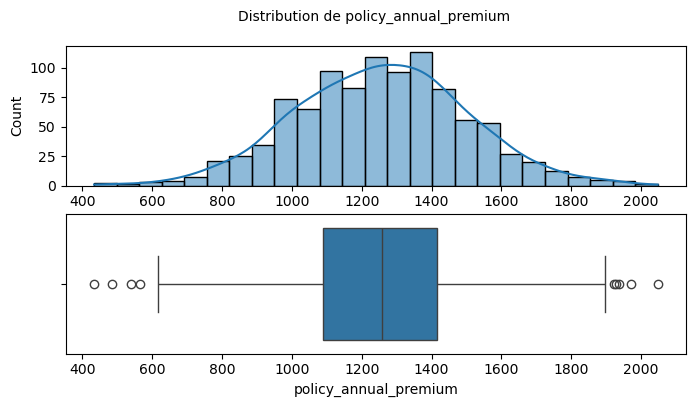

In [41]:
analyse_variable_quantitative('policy_annual_premium', df)


Statistiques de la variable: 

count        1000.0
mean      1101000.0
std       2297406.6
min      -1000000.0
25%             0.0
50%             0.0
75%             0.0
max      10000000.0
Name: umbrella_limit, dtype: float64

Nombre de valeur unique:
11

Nombre d'occurences par valeur:
umbrella_limit
 0           798
 6000000      57
 5000000      46
 4000000      39
 7000000      29
 3000000      12
 8000000       8
 9000000       5
 2000000       3
 10000000      2
-1000000       1
Name: count, dtype: int64

Pourcentage du nombre d'occurences par valeur en %:
umbrella_limit
 0           79.8
 6000000      5.7
 5000000      4.6
 4000000      3.9
 7000000      2.9
 3000000      1.2
 8000000      0.8
 9000000      0.5
 2000000      0.3
 10000000     0.2
-1000000      0.1
Name: proportion, dtype: float64

Occurrence la moins fréquente:
-1000000

Occurrence la plus fréquente:
0




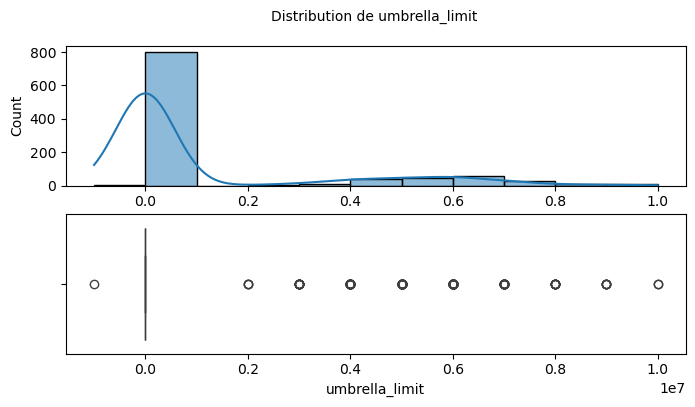

In [43]:
analyse_variable_quantitative('umbrella_limit', df)

In [26]:
df.fraud_reported.describe().round(2)

count     1000
unique       2
top          N
freq       753
Name: fraud_reported, dtype: object

In [27]:
df.fraud_reported.value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

In [28]:
df.fraud_reported.value_counts(normalize=True)

fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64

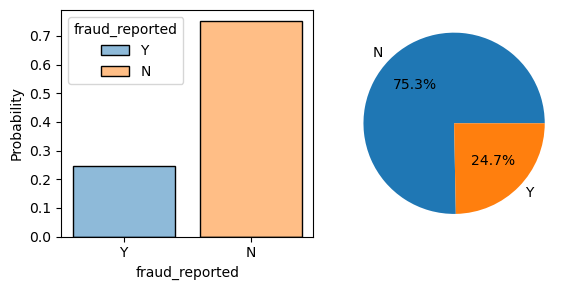

In [29]:
fig = plt.figure(figsize=(6,3))
sub1 = plt.subplot(1, 2, 1)
sns.histplot(data=df, x="fraud_reported", hue="fraud_reported",  shrink=.8, stat="probability")
sub2 = plt.subplot(1, 2, 2)
state_counts = df.fraud_reported.value_counts()
plt.pie(state_counts.values, 
        labels=state_counts.index, 
        autopct='%1.1f%%')
fig.tight_layout()
plt.show()

Valeurs manquantes en nombre

In [30]:
# Affichage des variables manquantes en nombre
df.isna().sum().sort_values(ascending=False)

_c39                           1000
authorities_contacted            91
months_as_customer                0
age                               0
policy_state                      0
policy_csl                        0
policy_number                     0
policy_bind_date                  0
policy_annual_premium             0
policy_deductable                 0
insured_sex                       0
umbrella_limit                    0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
insured_zip                       0
capital-gains                     0
capital-loss                      0
incident_type                     0
incident_date                     0
collision_type                    0
incident_severity                 0
incident_state                    0
insured_education_level           0
incident_city                     0
incident_location                 0
number_of_vehicles_involved       0
incident_hour_of_the_day    

Valeurs manquantes en pourcentage

* Affichage des valeurs nulles

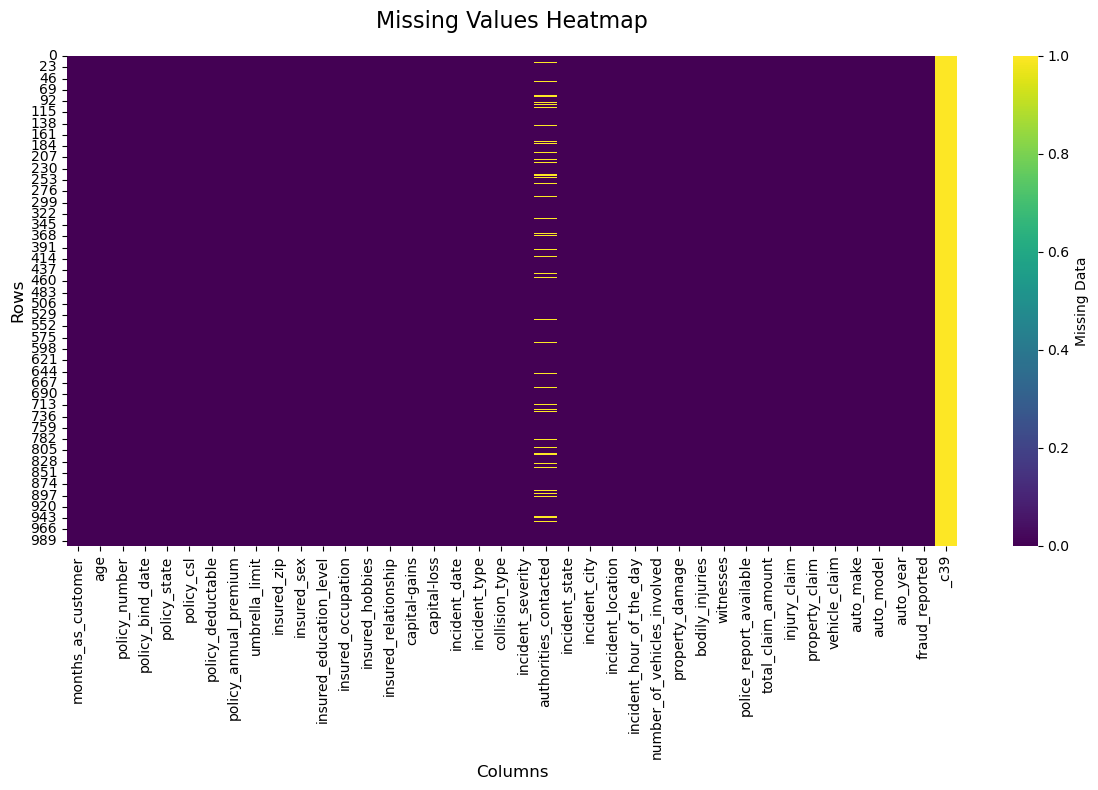

In [31]:
# Create a boolean mask for null values
null_mask = df.isnull()

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(null_mask, 
            cbar_kws={'label': 'Missing Data'},
            cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=16, pad=20)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
# Affichage des variables manquantes en nombre
pct_na = df.isna().sum()/len(df)*100
# pct_na.sort_values(ascending=False)

print(pct_na[pct_na>0])

authorities_contacted      9.1
_c39                     100.0
dtype: float64


Analyse de la variable "authorities_contacted" par rapport à la variable "police_report_available".
- on constate que pour 28 lignes dont la valeur est nulle pour la variable "authorities_contacted", il existe un rapport un rapport de la police. La police a donc été contactée.
- nous pouvons donc ramplacer les 28 valeurs nulles de la variable "authorities_contacted" par la valeur "Police"

In [33]:
pd.crosstab(df['police_report_available'], df['authorities_contacted'], dropna=False, normalize=False)

authorities_contacted,Ambulance,Fire,Other,Police,NaN
police_report_available,,,,,
?,69,77,73,97,27
NO,74,77,56,100,36
YES,53,69,69,95,28


In [34]:
pd.crosstab(df['incident_type'], df['authorities_contacted'], dropna=False, normalize=False)

authorities_contacted,Ambulance,Fire,Other,Police,NaN
incident_type,,,,,
Multi-vehicle Collision,100,111,100,108,0
Parked Car,0,0,0,34,50
Single Vehicle Collision,96,112,98,97,0
Vehicle Theft,0,0,0,53,41


Existance de lignes dupliquées

In [35]:
print("Lignes dupliquées dans la base de données")
print()
print(df[df.duplicated() == True])
print()
print("Conclusion: Il n'existe pas de lignes dupliquées dans la base de données")


Lignes dupliquées dans la base de données

Empty DataFrame
Columns: [months_as_customer, age, policy_number, policy_bind_date, policy_state, policy_csl, policy_deductable, policy_annual_premium, umbrella_limit, insured_zip, insured_sex, insured_education_level, insured_occupation, insured_hobbies, insured_relationship, capital-gains, capital-loss, incident_date, incident_type, collision_type, incident_severity, authorities_contacted, incident_state, incident_city, incident_location, incident_hour_of_the_day, number_of_vehicles_involved, property_damage, bodily_injuries, witnesses, police_report_available, total_claim_amount, injury_claim, property_claim, vehicle_claim, auto_make, auto_model, auto_year, fraud_reported, _c39]
Index: []

[0 rows x 40 columns]

Conclusion: Il n'existe pas de lignes dupliquées dans la base de données


Existance de valeurs abhérantes ou extremes

* Correlation entre les variables numériques et la variable cible

In [36]:
# to be deleted

df = pd.read_csv('insurance_claims.csv')

df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [37]:
# Codification des variables categorielles
df.fraud_reported = df.fraud_reported.replace({'Y' : 1, 'N' : 0})

df.authorities_contacted = df.authorities_contacted .fillna('UNKNOWN') # à voir

df.property_damage = df.property_damage.replace({'?':'UNKNOWN'})
df.police_report_available = df.police_report_available.replace({'?':'UNKNOWN'})
df.collision_type = df.collision_type.replace({'?':'UNKNOWN'})

df.insured_sex = df.insured_sex.replace({'MALE':1,'FEMALE':0})

df.insured_education_level = df.insured_education_level.replace({'High School': 1, 'College': 2, 'Associate': 2, 'JD': 3,
                                                             'Masters': 4, 'MD': 5, 'PhD': 6})
df.incident_severity = df.incident_severity.replace({'Minor Damage': 1, 'Major Damage': 2, 'Total Loss': 3, 'Trivial Damage': 4})




C:\Users\souha\AppData\Local\Temp\ipykernel_26556\3128106796.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fraud_reported = df.fraud_reported.replace({'Y' : 1, 'N' : 0})
C:\Users\souha\AppData\Local\Temp\ipykernel_26556\3128106796.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.insured_sex = df.insured_sex.replace({'MALE':1,'FEMALE':0})
C:\Users\souha\AppData\Local\Temp\ipykernel_26556\3128106796.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retai

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   int64  
 11  insured_education_level      1000 non-null   int64  
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [39]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,1,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,UNKNOWN,5070,780,780,3510,Mercedes,E400,2007,1,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,0,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,1,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,0,NaN


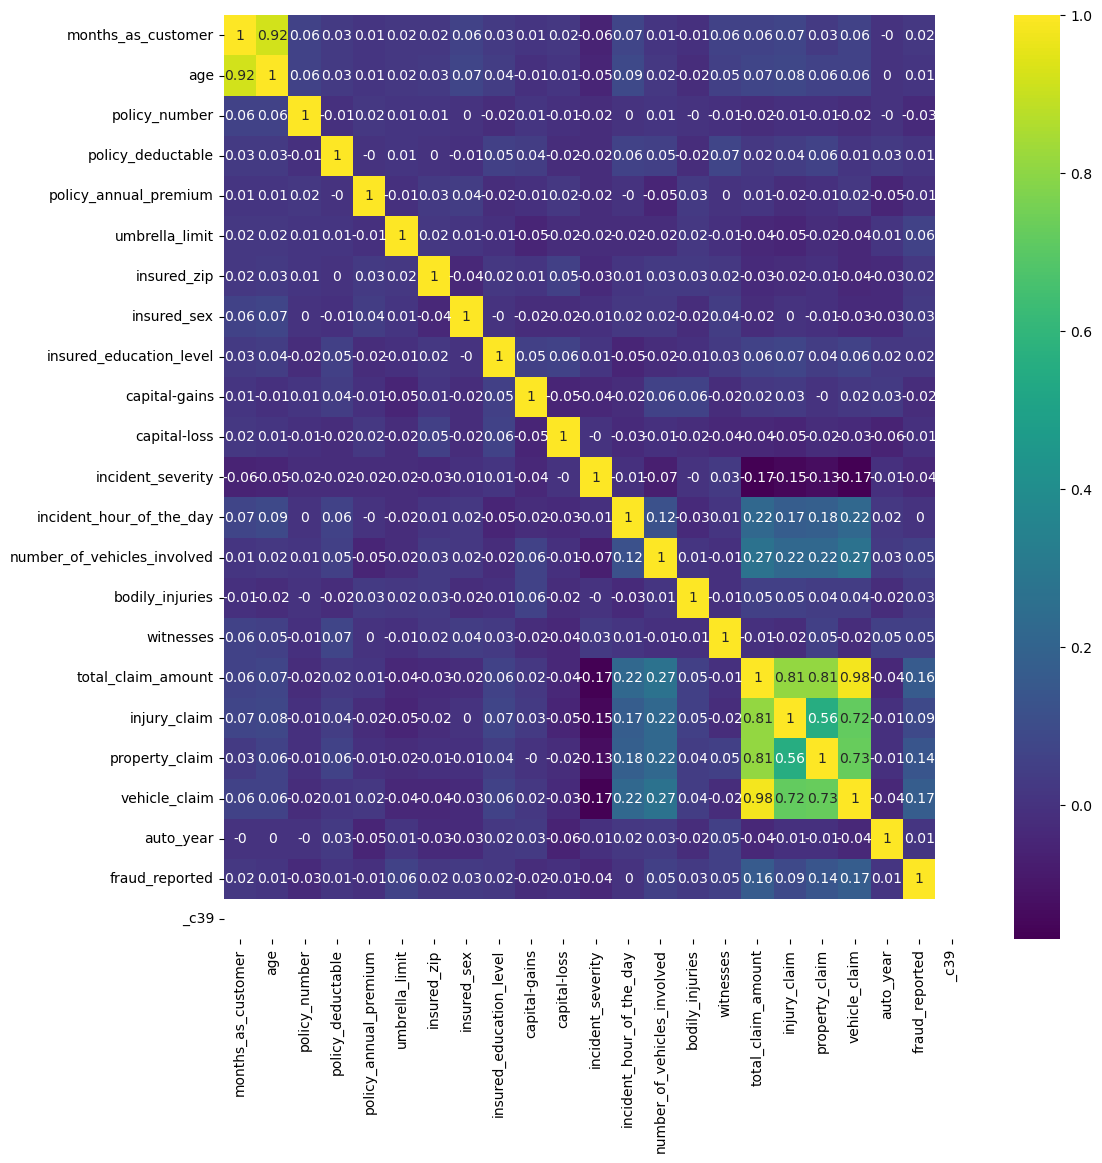

In [40]:
# calculate the correlation matrix on the numeric columns
corr = df.select_dtypes('number').corr().round(2)

# plot the heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='viridis')
plt.show()